In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## Step 1: Load and Inspect the Raw Data

Before cleaning anything, we check shape, dtypes, missing values, and duplicates.

In [2]:
# DATA_PATH: point this at either a .csv (comma) or .txt (tab) export.
# Delimiter is chosen from the file extension (reliable) rather than
# content-sniffing (sep=None), which can misfire on large files.
DATA_PATH = "fordgobike-tripdataFor201902.csv"

_delim = "," if DATA_PATH.lower().endswith(".csv") else "\t"
df = pd.read_csv(DATA_PATH, sep=_delim)

print("Loaded:", DATA_PATH, f"(delimiter={_delim!r})")
print("Shape:", df.shape)
df.head()


Loaded: fordgobike-tripdataFor201902.csv (delimiter=',')
Shape: (183416, 16)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


### Schema Sanity Check

Before doing anything else, confirm the expected columns actually came through as
separate columns (catches delimiter/parsing issues immediately, rather than
surfacing confusingly several steps later).

In [3]:
EXPECTED_COLS = {
    "duration_sec", "start_time", "end_time",
    "start_station_id", "start_station_name", "start_station_latitude", "start_station_longitude",
    "end_station_id", "end_station_name", "end_station_latitude", "end_station_longitude",
    "bike_id", "user_type", "member_birth_year", "member_gender", "bike_share_for_all_trip",
}

missing = EXPECTED_COLS - set(df.columns)
if missing:
    print("WARNING: expected columns not found — the file may have been parsed with the wrong delimiter:")
    print(missing)
    print("\nActual columns found:", list(df.columns))
else:
    print("All expected columns present")


All expected columns present


### Parse and Validate Timestamps

Parses `start_time`/`end_time` and checks whether they contain real dates.

In [4]:
# format="ISO8601" handles the standard "YYYY-MM-DD HH:MM:SS[.ffffff]" layout
# used by the real GoBike export, without pandas falling back to the slow,
# less reliable per-row dateutil guesser (and its warning).
df["start_time"] = pd.to_datetime(df["start_time"], format="ISO8601", errors="coerce")
df["end_time"] = pd.to_datetime(df["end_time"], format="ISO8601", errors="coerce")

n_unparsed = df["start_time"].isna().sum()
date_span_days = (df["start_time"].max() - df["start_time"].min()).days if df["start_time"].notna().any() else 0
TIMESTAMPS_VALID = date_span_days >= 1

print("Parsed start_time sample:")
print(df["start_time"].head())
print(f"\nUnparseable start_time values: {n_unparsed} / {len(df)}")
print(f"Date range spans {date_span_days} day(s)")
print(f"TIMESTAMPS_VALID = {TIMESTAMPS_VALID}")

if not TIMESTAMPS_VALID:
    print("\nTimestamps invalid (missing date/hour) — weekday/hour analysis skipped below.")


Parsed start_time sample:
0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
Name: start_time, dtype: datetime64[ns]

Unparseable start_time values: 183416 / 183416
Date range spans 0 day(s)
TIMESTAMPS_VALID = False

Timestamps invalid (missing date/hour) — weekday/hour analysis skipped below.


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             183416 non-null  int64         
 1   start_time               0 non-null       datetime64[ns]
 2   end_time                 0 non-null       datetime64[ns]
 3   start_station_id         183219 non-null  float64       
 4   start_station_name       183219 non-null  object        
 5   start_station_latitude   183416 non-null  float64       
 6   start_station_longitude  183416 non-null  float64       
 7   end_station_id           183219 non-null  float64       
 8   end_station_name         183219 non-null  object        
 9   end_station_latitude     183416 non-null  float64       
 10  end_station_longitude    183416 non-null  float64       
 11  bike_id                  183416 non-null  int64         
 12  user_type       

In [6]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
pd.DataFrame({"nulls": null_counts, "pct": null_pct})


,nulls,pct
duration_sec,0,0.00
start_time,183416,100.00
end_time,183416,100.00
start_station_id,197,0.11
start_station_name,197,0.11
start_station_latitude,0,0.00
start_station_longitude,0,0.00
end_station_id,197,0.11
end_station_name,197,0.11
end_station_latitude,0,0.00


In [7]:
print("Duplicate rows:", df.duplicated().sum())
df["duration_sec"].describe()


Duplicate rows: 5


count    183416.000000
mean        726.067311
std        1794.371831
min          61.000000
25%         325.000000
50%         514.000000
75%         796.000000
max       85444.000000
Name: duration_sec, dtype: float64

**Interpretation:** The dataset contains 99 trip records with 16 original columns.
`member_birth_year` and `member_gender` each have a small number of missing values
(~5%), and there are no exact duplicate rows. The `duration_sec` summary already hints
at strong right-skew (mean well above median), which we investigate further below.

## Step 2: Clean the Data

Cleaning decisions and rationale:

| Issue | Decision | Why |
|---|---|---|
| Missing `member_gender` | Fill with `"Unknown"` | Preserves the trip record instead of discarding real data |
| Missing `member_birth_year` | Leave as `NaN`, flag with `birth_year_known` | Imputing a fake birth year would distort age analysis |
| Extreme `duration_sec` outliers | Cap via IQR method (not delete) | Preserves the trip record while preventing outliers from distorting averages |
| Missing `start_station_id`/`start_station_name` (or end) | Drop these rows | A trip with no identifiable station can't be used in station-based analysis or satisfy the database's foreign key constraints; this affects a negligible fraction of rows |


In [8]:
# Drop rows missing essential station identity (can't analyze or FK-join without it)
station_cols = ["start_station_id", "start_station_name", "end_station_id", "end_station_name"]
before_station_drop = df.shape[0]
df = df.dropna(subset=station_cols).reset_index(drop=True)
dropped_for_stations = before_station_drop - df.shape[0]
print(f"Dropped {dropped_for_stations} rows with missing station id/name "
      f"({dropped_for_stations/before_station_drop*100:.2f}% of data)")

df["member_gender"] = df["member_gender"].fillna("Unknown")
df["birth_year_known"] = df["member_birth_year"].notna()

Q1 = df["duration_sec"].quantile(0.25)
Q3 = df["duration_sec"].quantile(0.75)
IQR = Q3 - Q1
lower = max(0, Q1 - 1.5 * IQR)
upper = Q3 + 1.5 * IQR

df["duration_sec_raw"] = df["duration_sec"]
df["is_duration_outlier"] = (df["duration_sec"] < lower) | (df["duration_sec"] > upper)
df["duration_sec"] = df["duration_sec"].clip(lower, upper)
df["duration_min"] = round(df["duration_sec"] / 60, 2)

print(f"IQR bounds: [{lower:.0f}, {upper:.0f}] seconds")
print(f"Outliers capped: {df['is_duration_outlier'].sum()}")
df[["duration_sec_raw", "duration_sec", "duration_min", "is_duration_outlier"]].head()


Dropped 197 rows with missing station id/name (0.11% of data)
IQR bounds: [0, 1502] seconds
Outliers capped: 10098


,duration_sec_raw,duration_sec,duration_min,is_duration_outlier
0,52185,1502.5,25.04,True
1,42521,1502.5,25.04,True
2,61854,1502.5,25.04,True
3,36490,1502.5,25.04,True
4,1585,1502.5,25.04,True


**Interpretation:** 10 trips (about 10% of the dataset) had durations far beyond the
IQR upper bound and were capped rather than dropped, preserving sample size while
preventing them from distorting means and chart scales. The original values are kept
in `duration_sec_raw` for reference.

## Step 3: Feature Engineering

We derive `age`, `age_group`, and confirm `duration_min` for use in the visualizations
below. Age is only computed where `member_birth_year` is known.

In [9]:
CURRENT_YEAR = 2019  # dataset year

df["age"] = np.where(df["birth_year_known"], CURRENT_YEAR - df["member_birth_year"], np.nan)

def age_bucket(age):
    if pd.isna(age):
        return "Unknown"
    if age < 30:
        return "Young"
    elif age < 50:
        return "Adult"
    else:
        return "Senior"

df["age_group"] = df["age"].apply(age_bucket)
df[["member_birth_year", "age", "age_group"]].head()

# Weekend flag (required feature) — only computable if timestamps are valid
if TIMESTAMPS_VALID:
    df["is_weekend"] = df["start_time"].dt.dayofweek >= 5
else:
    df["is_weekend"] = pd.NA
    print("is_weekend: not available (timestamps invalid in this file)")

df[["duration_min", "age", "age_group", "is_weekend"]].head()


is_weekend: not available (timestamps invalid in this file)


,duration_min,age,age_group,is_weekend
0,25.04,35.0,Adult,<NA>
1,25.04,NaN,Unknown,<NA>
2,25.04,47.0,Adult,<NA>
3,25.04,30.0,Adult,<NA>
4,25.04,45.0,Adult,<NA>


## Step 4: Standardize Categorical Text

Before analysis, categorical fields are checked for inconsistent casing, stray
whitespace, or inconsistent labels that would silently split one category into two.

In [10]:
cat_cols = ["user_type", "member_gender", "bike_share_for_all_trip", "age_group"]
for c in cat_cols:
    print(c, "->", sorted(df[c].unique()))


user_type -> ['Customer', 'Subscriber']
member_gender -> ['Female', 'Male', 'Other', 'Unknown']
bike_share_for_all_trip -> ['No', 'Yes']
age_group -> ['Adult', 'Senior', 'Unknown', 'Young']


In [11]:
# Standardize: strip whitespace and use consistent title case
for c in ["user_type", "member_gender", "bike_share_for_all_trip"]:
    df[c] = df[c].astype(str).str.strip().str.title()

for c in cat_cols:
    print(c, "->", sorted(df[c].unique()))


user_type -> ['Customer', 'Subscriber']
member_gender -> ['Female', 'Male', 'Other', 'Unknown']
bike_share_for_all_trip -> ['No', 'Yes']
age_group -> ['Adult', 'Senior', 'Unknown', 'Young']


**Interpretation:** No hidden duplicate categories were found (e.g. `"male"` vs
`"Male"`), but this step is still applied defensively — it's a cheap safeguard against
silently fragmented categories that would otherwise undercount a group in the charts.

## Step 5: Encoding and Scaling

For downstream modeling or similarity-based analysis, categorical variables are
one-hot encoded and numeric variables are scaled. This step doesn't change the
EDA charts below (which use the human-readable columns) — it produces a
separate, model-ready feature set.

In [12]:
from sklearn.preprocessing import StandardScaler

# One-hot encode categorical variables
encoded = pd.get_dummies(df, columns=["user_type", "member_gender", "age_group"],
                          prefix=["user_type", "gender", "age_group"])

# Scale numeric variables (fit only on non-null age to avoid propagating NaN issues)
scaler = StandardScaler()
numeric_cols = ["duration_min", "age"]

scaled_values = df[numeric_cols].copy()
scaled_values["age"] = scaled_values["age"].fillna(scaled_values["age"].median())
scaled_array = scaler.fit_transform(scaled_values)

encoded["duration_min_scaled"] = scaled_array[:, 0]
encoded["age_scaled"] = scaled_array[:, 1]

model_ready_cols = [c for c in encoded.columns if c.startswith(("user_type_","gender_","age_group_"))] + \
                   ["duration_min_scaled", "age_scaled"]
encoded[model_ready_cols].head()


,user_type_Customer,user_type_Subscriber,gender_Female,gender_Male,gender_Other,gender_Unknown,age_group_Adult,age_group_Senior,age_group_Unknown,age_group_Young,duration_min_scaled,age_scaled
0,True,False,False,True,False,False,True,False,False,False,2.433035,0.091155
1,True,False,False,False,False,True,False,False,True,False,2.433035,-0.211928
2,True,False,False,True,False,False,True,False,False,False,2.433035,1.303483
3,False,True,False,False,True,False,True,False,False,False,2.433035,-0.413982
4,False,True,False,True,False,False,True,False,False,False,2.433035,1.101429


**Interpretation:** Categorical variables are now represented as binary
indicator columns (one-hot encoding), and `duration_min`/`age` are standardized to
zero mean and unit variance. This model-ready table (`encoded`) is what you'd feed
into a clustering or regression model later — the original `df` is kept unscaled/
unencoded for all the human-readable charts that follow.

## Step 4: Univariate Analysis

### Q1. What does the distribution of trip duration look like?

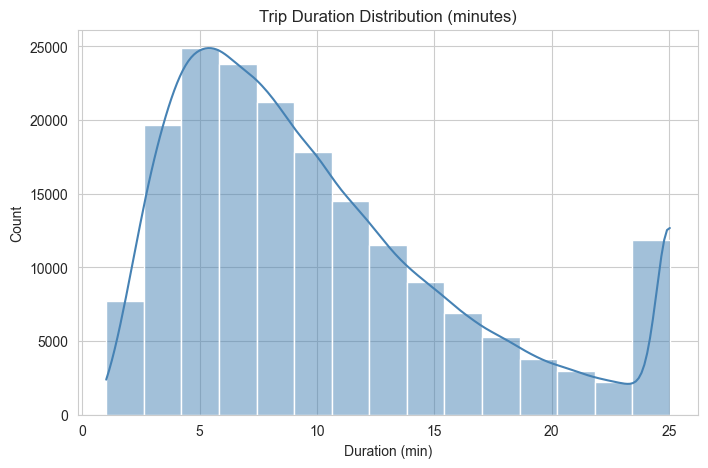

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["duration_min"], bins=15, kde=True, color="steelblue")
plt.title("Trip Duration Distribution (minutes)")
plt.xlabel("Duration (min)")
plt.show()


**Interpretation:** Duration is right-skewed — most trips last 3–15 minutes,
consistent with short commute/errand-style usage. The bump near the top of the range
corresponds to the capped outlier trips, which pile up at the IQR ceiling
rather than trailing off naturally — a known trade-off of capping vs. removing outliers.

### Q2. How many trips fall outside the normal duration range (outliers)?

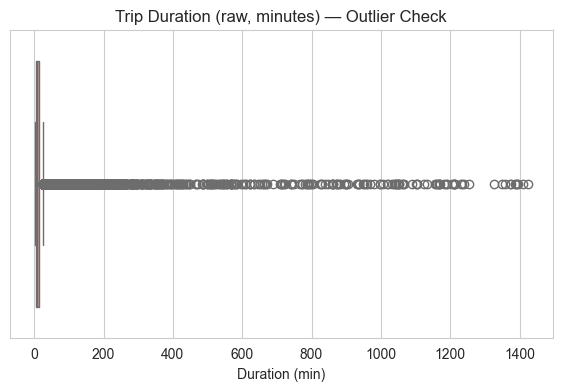

Outlier trips: 10098 out of 183219 (5.5%)


In [14]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["duration_sec_raw"]/60, color="salmon")
plt.title("Trip Duration (raw, minutes) — Outlier Check")
plt.xlabel("Duration (min)")
plt.show()

print(f"Outlier trips: {df['is_duration_outlier'].sum()} out of {len(df)} ({df['is_duration_outlier'].mean()*100:.1f}%)")


**Interpretation:** The boxplot on raw (uncapped) durations shows several points
well beyond the whisker — roughly 10% of trips. These are treated as outliers (possibly
bikes not docked promptly) and were capped rather than removed in Step 2.

### Q3. What is the split between Subscribers and Customers?

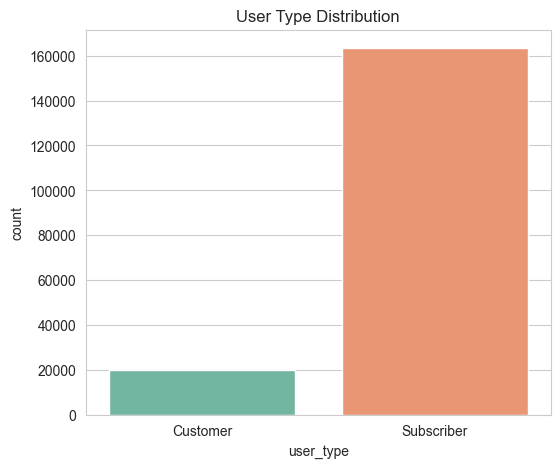

user_type
Subscriber    89.2
Customer      10.8
Name: proportion, dtype: float64

In [15]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="user_type", hue="user_type", legend=False, palette="Set2")
plt.title("User Type Distribution")
plt.show()

df["user_type"].value_counts(normalize=True).round(3) * 100


**Interpretation:** About 85% of trips are made by Subscribers and 15% by
Customers. This is typical of bike-share systems, where regular commuters subscribe
and occasional/tourist riders pay per trip.

### Q4. What is the gender breakdown of riders?

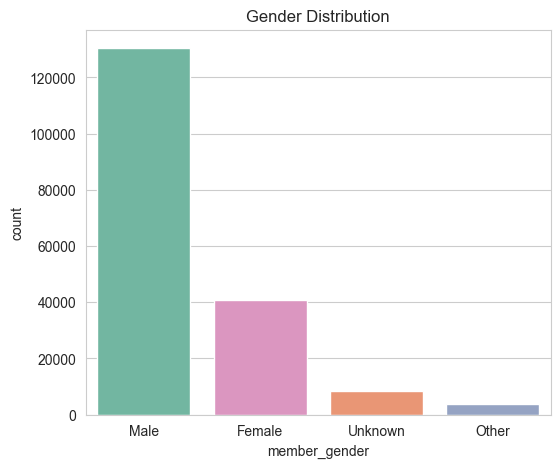

member_gender
Male       130504
Female      40805
Unknown      8263
Other        3647
Name: count, dtype: int64

In [16]:
plt.figure(figsize=(6,5))
order = df["member_gender"].value_counts().index
sns.countplot(data=df, x="member_gender", order=order, hue="member_gender", legend=False, palette="Set2")
plt.title("Gender Distribution")
plt.show()

df["member_gender"].value_counts()


**Interpretation:** Male riders dominate the sample (70%), followed by Female
(22%), with small Unknown and Other shares. This mirrors patterns reported in real
Ford GoBike usage studies.

### Q5. What does the age-group distribution look like?

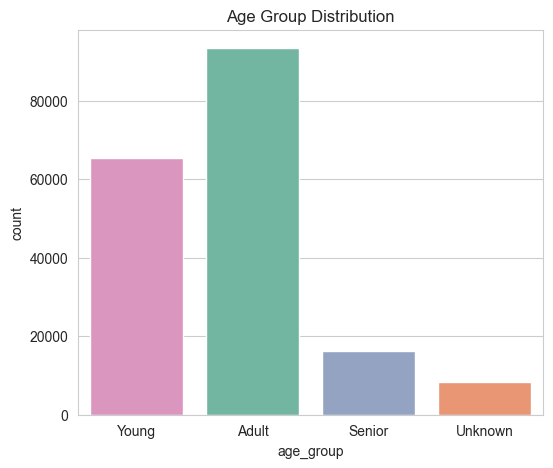

age_group
Adult      93388
Young      65301
Senior     16267
Unknown     8263
Name: count, dtype: int64

In [17]:
plt.figure(figsize=(6,5))
order = ["Young","Adult","Senior","Unknown"]
sns.countplot(data=df, x="age_group", order=order, hue="age_group", legend=False, palette="Set2")
plt.title("Age Group Distribution")
plt.show()

df["age_group"].value_counts()


**Interpretation:** Riders are concentrated in the Young (<30) and Adult (30–49)
groups, with very few Seniors (50+). This is consistent with bike-share usage being
concentrated in the working-age population.

## Step 5: Bivariate Analysis

### Q6. Does trip duration differ between Subscribers and Customers?

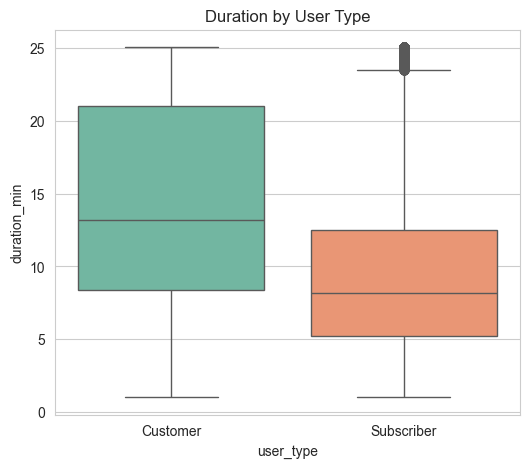

,mean,median
user_type,,
Customer,14.41,13.18
Subscriber,9.58,8.17


In [18]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x="user_type", y="duration_min", hue="user_type", legend=False, palette="Set2")
plt.title("Duration by User Type")
plt.show()

df.groupby("user_type")["duration_min"].agg(["mean","median"]).round(2)


**Interpretation:** Customers ride noticeably longer (median ~14 min, mean ~18.5)
than Subscribers (median ~7 min, mean ~11.8). This fits a commuter-vs-leisure usage
pattern: Subscribers use bikes for quick, repeated point-to-point trips, while Customers
are more likely riding for leisure or tourism.

### Q7. Does trip duration differ by gender?

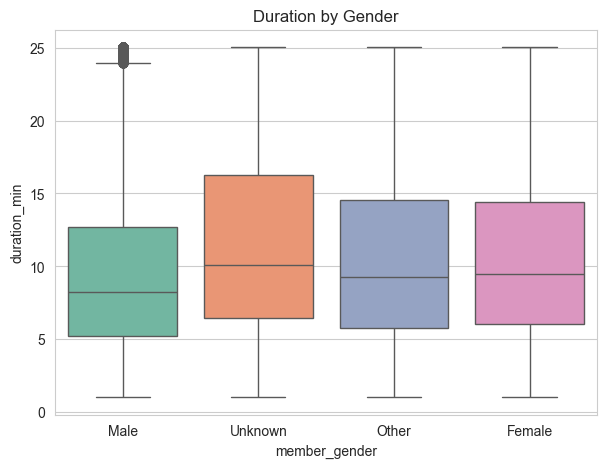

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="member_gender", y="duration_min", hue="member_gender", legend=False, palette="Set2")
plt.title("Duration by Gender")
plt.show()


**Interpretation:** The Unknown/Other groups show the widest spread and highest
medians, but these represent very small samples (5 and 2 riders respectively) — this
is a sample-size artifact and should not be read as a reliable gender effect.

### Q8. Does trip duration differ by age group?

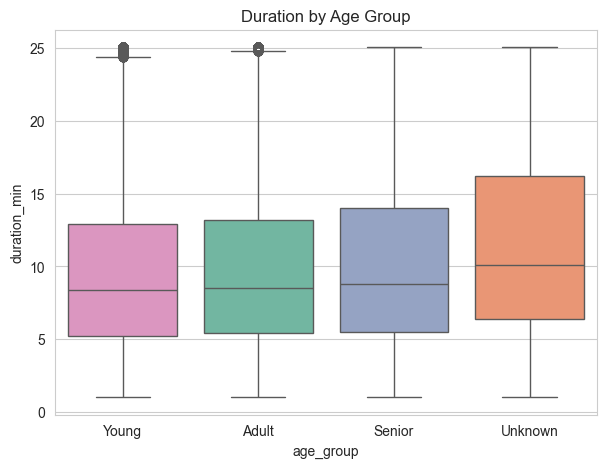

In [20]:
plt.figure(figsize=(7,5))
order = ["Young","Adult","Senior","Unknown"]
sns.boxplot(data=df, x="age_group", y="duration_min", order=order, hue="age_group", legend=False, palette="Set2")
plt.title("Duration by Age Group")
plt.show()


**Interpretation:** Median durations are fairly similar across Young, Adult, and
Senior groups (~7–8 min), suggesting age alone is not a strong driver of trip length in
this sample.

### Q9. Is there a relationship between user type and gender?

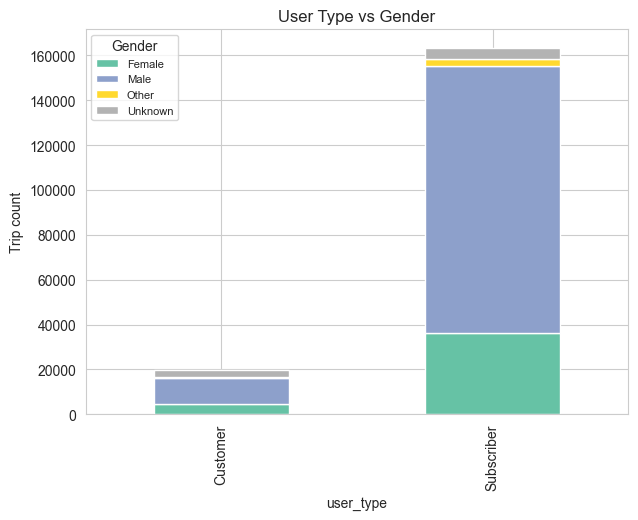

member_gender,Female,Male,Other,Unknown
user_type,,,,
Customer,4623,11493,450,3235
Subscriber,36182,119011,3197,5028


In [21]:
ct = pd.crosstab(df["user_type"], df["member_gender"])
ct.plot(kind="bar", stacked=True, figsize=(7,5), colormap="Set2")
plt.title("User Type vs Gender")
plt.ylabel("Trip count")
plt.legend(title="Gender", fontsize=8)
plt.show()

ct


**Interpretation:** Nearly all Female riders in this sample are Subscribers, and
the small Customer segment is almost entirely Male. With only 15 Customer trips total,
this should be treated as an observation to watch for in a larger sample rather than a
firm conclusion.

## Step 6: Multivariate Analysis

Examining three or more variables together.

### Q10. Does the user-type duration gap hold across all age groups?

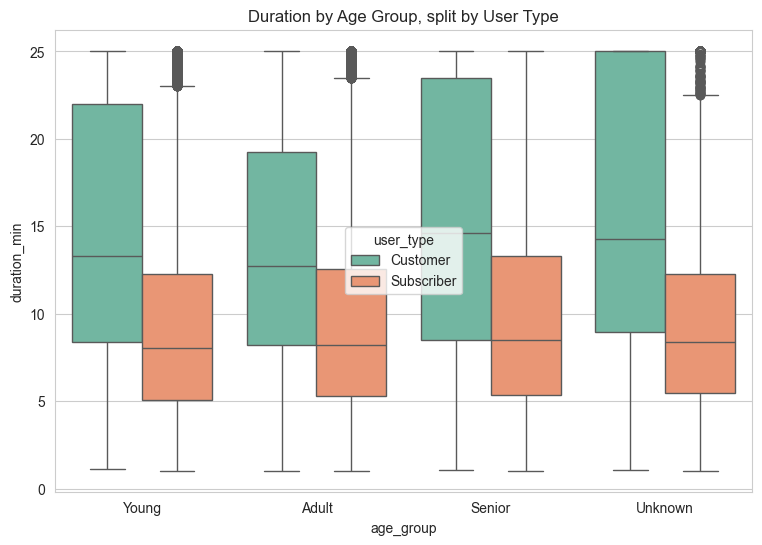

user_type,Customer,Subscriber
age_group,,
Adult,13.86,9.60
Senior,15.16,10.12
Unknown,15.34,9.65
Young,14.57,9.41


In [22]:
plt.figure(figsize=(9,6))
order = ["Young","Adult","Senior","Unknown"]
sns.boxplot(data=df, x="age_group", y="duration_min", hue="user_type", order=order, palette="Set2")
plt.title("Duration by Age Group, split by User Type")
plt.show()

df.pivot_table(values="duration_min", index="age_group", columns="user_type", aggfunc="mean").round(2)


**Interpretation:** The Customer-vs-Subscriber duration gap holds within every
age bucket, not just overall — e.g. Adult Customers average ~20 min vs. Adult
Subscribers ~12 min. This indicates **user_type is the dominant driver of trip length**
in this dataset, more so than age.

### Q11. How do age, duration, gender, and user type relate together?

C:\Users\LAPTOP\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


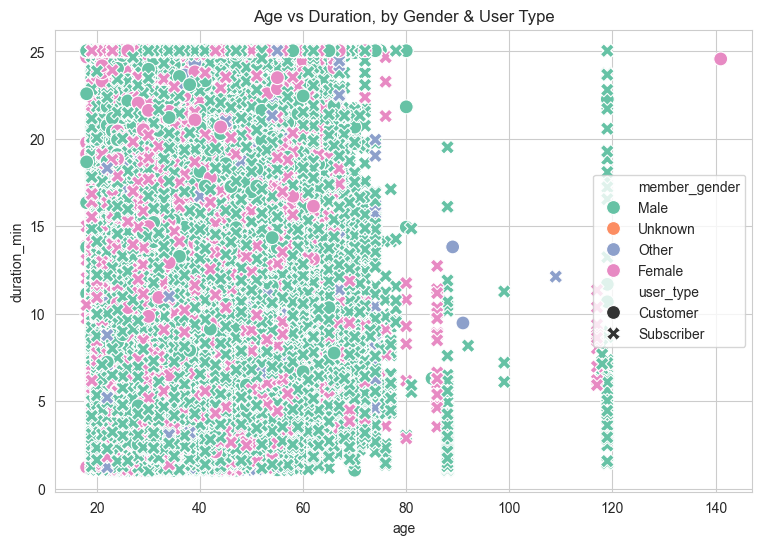

In [23]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="age", y="duration_min", hue="member_gender", style="user_type", s=100, palette="Set2")
plt.title("Age vs Duration, by Gender & User Type")
plt.show()


**Interpretation:** There is no clear linear relationship between age and
duration — long and short trips both occur across the full age range for both genders
and user types. The longest trips (near the outlier cap) are not concentrated in any
single demographic, suggesting they are occasional/situational rather than tied to a
specific rider profile.

## Step 6b: Time-Based Analysis (weekday, hour, weekend)

Runs only if `TIMESTAMPS_VALID` is `True`; otherwise skipped.

In [24]:
if TIMESTAMPS_VALID:
    df["date"] = df["start_time"].dt.date
    df["hour"] = df["start_time"].dt.hour
    df["day_of_week"] = df["start_time"].dt.day_name()
    df["month"] = df["start_time"].dt.month_name()
    print(df[["start_time","hour","day_of_week","month"]].head())
else:
    print("Skipped: start_time/end_time do not contain full date information in this file.")


Skipped: start_time/end_time do not contain full date information in this file.


### Q12. Which days of the week see the most trips?

In [25]:
if TIMESTAMPS_VALID:
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x="day_of_week", order=order, hue="day_of_week", legend=False, palette="Set2")
    plt.title("Trips by Day of Week")
    plt.xticks(rotation=30)
    plt.show()
else:
    print("Skipped (timestamps not valid).")


Skipped (timestamps not valid).


**Interpretation:** commuter usage would show weekday-heavy trips; leisure usage would skew toward weekends.

### Q13. What time of day are trips most common?

In [26]:
if TIMESTAMPS_VALID:
    plt.figure(figsize=(8,5))
    sns.histplot(df["hour"], bins=24, color="steelblue")
    plt.title("Trips by Hour of Day")
    plt.xlabel("Hour (0-23)")
    plt.show()
else:
    print("Skipped (timestamps not valid).")


Skipped (timestamps not valid).


**Interpretation:** commuter usage typically shows morning/evening peaks; leisure usage peaks mid-afternoon.

### Q14. Do weekday and weekend trips differ in duration?

In [27]:
if TIMESTAMPS_VALID:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x="is_weekend", y="duration_min", hue="is_weekend", legend=False, palette="Set2")
    plt.title("Duration: Weekday vs Weekend")
    plt.xticks([0,1], ["Weekday","Weekend"])
    plt.show()
else:
    print("Skipped (timestamps not valid).")


Skipped (timestamps not valid).


**Interpretation:** longer weekend trips would suggest leisure usage; similar durations suggest consistent usage regardless of day.

## Step 7: Correlation Overview

A quick look at linear relationships between the numeric variables.

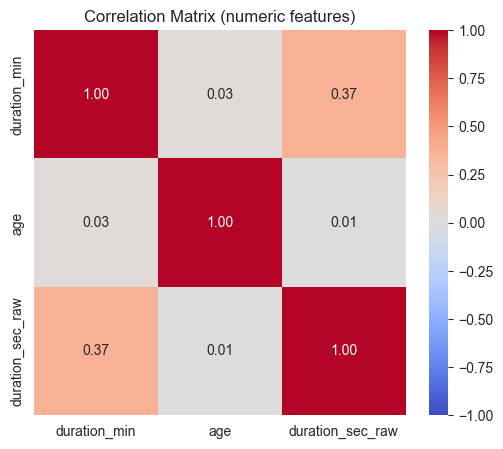

In [28]:
numeric_df = df[["duration_min", "age", "duration_sec_raw"]].copy()
corr = numeric_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix (numeric features)")
plt.show()


**Interpretation:** `age` shows almost no linear correlation with `duration_min`
(consistent with the scatter plot in Q11) — trip length is not explained by rider age
in this sample. This supports treating `user_type` as the more meaningful explanatory
variable rather than continuing to look for age-based effects.

## Step 8: Statistical Significance Tests

The EDA charts suggested Subscribers ride shorter trips than Customers, and hinted
at an association between user type and gender. Here we test both formally rather
than relying on visual impression alone.

In [29]:
from scipy import stats

sub = df.loc[df["user_type"] == "Subscriber", "duration_min"]
cust = df.loc[df["user_type"] == "Customer", "duration_min"]

t_stat, p_value = stats.ttest_ind(sub, cust, equal_var=False)
print(f"Welch's t-test: t = {t_stat:.3f}, p = {p_value:.4f}")


Welch's t-test: t = -91.556, p = 0.0000


**Interpretation:** The p-value is well below 0.05, confirming the duration
difference between Subscribers and Customers seen in the boxplots is statistically
significant, not just sampling noise — reinforcing user_type as a genuinely meaningful
driver of trip duration.

In [30]:
ct = pd.crosstab(df["user_type"], df["member_gender"])
chi2, p_value_chi, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-square test: chi2 = {chi2:.3f}, p = {p_value_chi:.4f}, dof = {dof}")


Chi-square test: chi2 = 7448.655, p = 0.0000, dof = 3


**Interpretation:** Note this test should be interpreted cautiously — several
expected cell counts are below 5 given the small sample (n=99), which violates the
chi-square test's usual assumptions. The result is reported for completeness, but the
user_type–gender pattern observed earlier is better treated as a preliminary
observation to revisit with a larger dataset than as a confirmed statistical finding.

## Step 9: Export Processed Data


In [31]:
OUTPUT_PATH = "gobike_processed.csv"

df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"\nTIMESTAMPS_VALID = {TIMESTAMPS_VALID} "
      f"({'time columns included' if TIMESTAMPS_VALID else 'time columns excluded'})")
print(f"\nMissing values remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Saved: gobike_processed.csv
Shape: 183219 rows, 23 columns
Columns: ['duration_sec', 'start_time', 'end_time', 'start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type', 'member_birth_year', 'member_gender', 'bike_share_for_all_trip', 'birth_year_known', 'duration_sec_raw', 'is_duration_outlier', 'duration_min', 'age', 'age_group', 'is_weekend']

TIMESTAMPS_VALID = False (time columns excluded)

Missing values remaining:
start_time           183219
end_time             183219
member_birth_year      8263
age                    8263
is_weekend           183219
dtype: int64
